PRÁCTICA MACHINE LEARNING: Predecir el mercado de valores

 ¡Hola y bienvenido a la Práctica de Machine Learning más difícil del mundo!

Este notebook está diseñado para ayudarte a comenzar con la práctica.

En este cuaderno vamos a:

- Descargar y explorar el conjunto de datos
- Entrenar y evaluar este primer modelo de aprendizaje automático
- Implementar el modelo para comenzar a realizar predicciones

In [55]:
# Instala dependencias
!pip install -q --upgrade numerapi pandas pyarrow matplotlib lightgbm scikit-learn scipy cloudpickle==3.1.1
!pip install -q --no-deps numerai-tools

# Gráficas Inline
%matplotlib inline


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


1.- DATASET

A alto nivel, trabajaremos con un conjunto de datos tabulares que describe el mercado de valores a lo largo del tiempo.

Cada fila representa una acción en un momento específico, donde "id" es la identificación de la acción y "era" es la fecha. 

Las características describen los atributos de la acción (por ejemplo, el ratio Price/Earning) conocidos en una fecha dada, y "target" es una medida de rendimientos a 20 días.

El conjunto de datos está ofuscado, lo que significa que los identificadores de acciones (stocks) subyacentes, los nombres de las características y las definiciones de objetivos son anónimos. Esto hace que podamos trabajar con estos datos de forma gratuita y que puedan modelarse sin ningún conocimiento (¡o sesgo!) del dominio financiero.

Descargamos los datos históricos de entrenamiento y echamos un vistazo de cerca.

In [56]:
# Inicializa NumerAPI - el cliente oficial de Python para acceder al API de nuestro conjunto de datos.
from numerapi import NumerAPI
napi = NumerAPI()

# Set data version to one of the latest datasets
DATA_VERSION = "v5.0"

# Imprime todos los ficheros del conjunto de datos disponibles para descargar los más recientes.
[f for f in napi.list_datasets() if f.startswith(DATA_VERSION)]

['v5.0/features.json',
 'v5.0/live.parquet',
 'v5.0/live_benchmark_models.parquet',
 'v5.0/live_example_preds.csv',
 'v5.0/live_example_preds.parquet',
 'v5.0/meta_model.parquet',
 'v5.0/train.parquet',
 'v5.0/train_benchmark_models.parquet',
 'v5.0/validation.parquet',
 'v5.0/validation_benchmark_models.parquet',
 'v5.0/validation_example_preds.csv',
 'v5.0/validation_example_preds.parquet']

In [57]:
import pandas as pd
import json

# Descarga los datos de entrenamiento y los metadatos de las características
# Esto tomará unos pocos minutos 🍵
napi.download_dataset(f"{DATA_VERSION}/train.parquet");
napi.download_dataset(f"{DATA_VERSION}/features.json");

# Carga solo el conjunto de features "medium" para reducir el uso de memoria y acelerar el entrenamiento del modelo 
# O bien, utiliza el conjunto de features "all" para usar todas las características
# En este ejemplo descargaremos solo el "small"
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]
for feature_set in ["small", "medium", "all"]:
  print(feature_set, len(feature_sets[feature_set]))

feature_set = feature_sets["small"]
#feature_cols = feature_metadata["feature_sets"]["small"]
#train = pd.read_parquet(f"{DATA_VERSION}/train.parquet", columns=["era"] + feature_cols + ["target"])
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)

# Reduce la muestra, tomando cada cuatro eras, para reducir el uso de memoria y acelerar el entrenamiento del modelo (toma las eras 0001, 0005, 0009, ...)
# Comenta la línea a continuación para utilizar todos los datos.
train = train[train["era"].isin(train["era"].unique()[::4])]
train

2025-11-04 19:25:23,992 INFO numerapi.utils: target file already exists
2025-11-04 19:25:23,994 INFO numerapi.utils: download complete
2025-11-04 19:25:24,886 INFO numerapi.utils: target file already exists
2025-11-04 19:25:24,887 INFO numerapi.utils: download complete


small 42
medium 705
all 2376


,era,target,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,...,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,0.25,2,2,2,2,2,0,1,2,...,4,1,1,3,0,2,2,3,3,2
n003bba8a98662e4,0001,0.25,2,2,2,2,2,1,4,2,...,4,2,0,0,0,2,2,4,4,2
n003bee128c2fcfc,0001,0.75,2,2,2,2,2,2,2,2,...,3,1,1,0,1,2,2,0,3,2
n0048ac83aff7194,0001,0.25,2,2,2,2,2,1,4,2,...,1,3,4,1,2,2,2,2,0,2
n0055a2401ba6480,0001,0.25,2,2,2,2,2,0,0,2,...,1,0,1,0,0,2,2,1,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nffc2d5e4b79a7ae,0573,0.00,1,2,1,0,3,2,1,1,...,2,2,1,2,3,3,3,2,2,1
nffc9844c1c7a6a9,0573,0.25,2,1,2,1,4,2,2,4,...,4,0,0,3,1,3,3,2,3,2
nffd79773f4109bb,0573,0.50,3,4,0,3,4,1,0,1,...,3,0,0,0,1,1,4,0,1,2


ERAS:

Como se mencionó anteriormente, cada "era" corresponde a una fecha diferente. Cada "era" tiene exactamente una semana de diferencia.

Es útil pensar en filas de acciones dentro de la misma "era" como un solo ejemplo. A lo largo de este notebook hablaremos de cosas "por era". Por ejemplo, el número de filas por "era" representa el conjunto de acciones (stocks) dentro de las posibilidades de inversión de algún fondo en esa fecha.

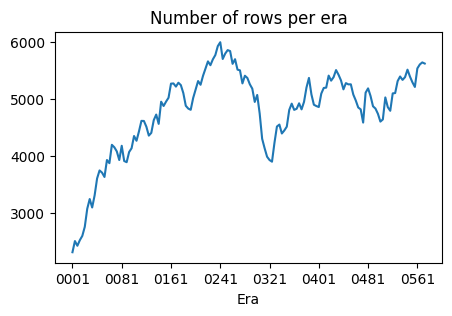

In [58]:
# Muestra el número de filas por era
train.groupby("era").size().plot(title="Number of rows per era", figsize=(5, 3), xlabel="Era");

FEATURES:

Como se mencionó anteriormente, las características son atributos cuantitativos de cada acción: fundamentos como la relación P/E (precio/beneficio), señales técnicas como el RSI, datos de mercado como el interés a corto, datos secundarios como las calificaciones de los analistas y mucho más.

La definición subyacente de cada característica no es importante, solo debes saber que se han incluido estas características en el conjunto de datos porque se cree que pueden ser relevantes para predecir el "target".

In [59]:
# Número de características
len(feature_set)

42

Los valores de las características se agrupan en 5 contenedores iguales: 0, 1, 2, 3, 4. Esta fuerte estandarización de los valores de las características tiene como objetivo evitar el overfitting, ya que los valores subyacentes son extremadamente ruidosos.

Si faltan datos de una característica particular para esa era (más común en las primeras eras), todos los valores se establecen en 2.


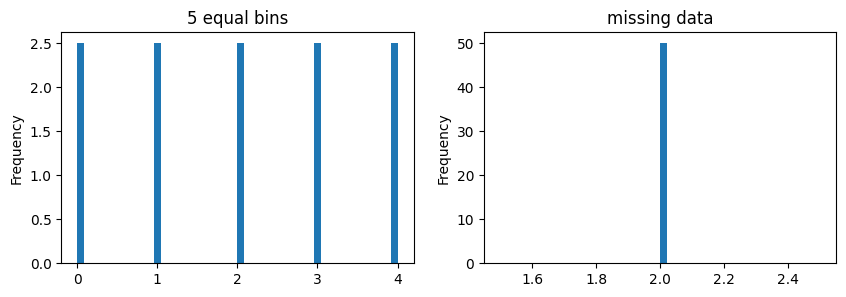

In [60]:
# Compara la distribución de una característica particular (feature_cols[-1]) entre dos períodos diferentes (first_era y last_era) en el conjunto de datos train.
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
first_era = train[train["era"] == train["era"].unique()[0]]
last_era = train[train["era"] == train["era"].unique()[-1]]
last_era[feature_set[-1]].plot(kind="hist", title="5 equal bins", density=True, bins=50, ax=ax1);
first_era[feature_set[-1]].plot(kind="hist", title="missing data", density=True, bins=50, ax=ax2);

TARGET:

El "target" es una medida de los rendimientos del mercado de valores a 20 días. Específicamente, es una medida de rendimientos "específicos de acciones" que no se "explican" por tendencias más amplias en el mercado, país, sector o "factores" bien conocidos.

Los valores del "target" se agrupan en 5 contenedores desiguales: 0, 0,25, 0,5, 0,75, 1,0. Nuevamente, esta fuerte estandarización de los valores de target tiene como objetivo evitar el overfitting, ya que los valores subyacentes son extremadamente ruidosos.

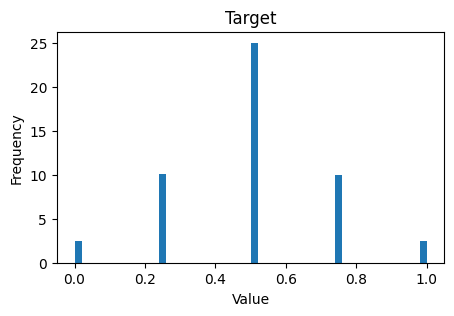

In [61]:
# Histograma (densidad) de "target"
train["target"].plot(kind="hist", title="Target", figsize=(5, 3), xlabel="Value", density=True, bins=50);

2.- MODELING

Entrenamiento del modelo:

Eres libre de utilizar cualquier algoritmo visto en clase. Pero, en este ejemplo, usaremos LGBMRegressor, basado en árboles de decisión para predecir variables continuas. Es una opción popular para las predicciones de este tipo.

In [62]:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html 
import lightgbm as lgb #En mi mac, tuve que instalar libomp: "brew install libomp"

# https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html
model = lgb.LGBMRegressor(
  n_estimators=2000,
  learning_rate=0.01,
  max_depth=5,
  num_leaves=2**5-1,
  colsample_bytree=0.1
)

# This will take a few minutes 🍵
model.fit(
  train[feature_set],
  train["target"]
);

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001220 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 688184, number of used features: 42
[LightGBM] [Info] Start training from score 0.500008


Ahora hagamos algunas predicciones con los datos de validación para evaluar el rendimiento de nuestro modelo.

In [63]:
# Descarga validation data 
# Esto tomará unos pocos minutos 🍵
napi.download_dataset(f"{DATA_VERSION}/validation.parquet");

# Carga el validation data, filtrando por data_type == "validation"
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

# Reduce la muestra a cada cuarta era para reducir el uso de memoria y acelerar la evaluación
# Comenta la siguiente línea para usar todos los datos (mayor uso de memoria, inferencia más lenta, evaluación más precisa)
validation = validation[validation["era"].isin(validation["era"].unique()[::4])]

# Las eras están separadas por una semana, pero los "targets" miran 4 semanas en el futuro, por lo que debemos "embargar" las 4 eras posteriores a nuestra última "era" para evitar fuga de datos.
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(4)]]
validation = validation[~validation["era"].isin(eras_to_embargo)]

# Genera predicciones respecto a las características de validación fuera de la muestra.
# Esto tomará unos pocos minutos 🍵
validation["prediction"] = model.predict(validation[feature_set])
validation[["era", "prediction", "target"]]

2025-11-04 19:25:43,425 INFO numerapi.utils: target file already exists
2025-11-04 19:25:43,426 INFO numerapi.utils: download complete


,era,prediction,target
id,,,
n000c290e4364875,0579,0.494547,0.50
n002a15bc5575bbb,0579,0.517560,0.25
n00309caaa0f955e,0579,0.515683,0.75
n0039cbdcf835708,0579,0.509313,0.50
n004143458984f89,0579,0.483896,0.50
...,...,...,...
nffc45fef92f9990,1183,0.500537,0.50
nffcd993886ef112,1183,0.487059,0.25
nffd2f8483ddb3cc,1183,0.512208,0.25


Evaluación del rendimiento:

La métrica de puntuación principal que usaremos se llama CORR (practica_corr), que es una variante específica de para este caso de uso del coeficiente de correlación de Pearson.

Esta métrica está diseñada para "alinear los incentivos" entre el modelo y el desempeño de un fondo de inversión. Es decir, un modelo con una buena puntuación CORR debería ayudar a un inversor a obtener buenos rendimientos.

In [64]:
from scipy import stats
import numpy as np

# La principal métrica de scoring:
def practica_corr(preds, target):
    # clasifica (manteniendo vínculos) y luego gaussianiza las predicciones para estandarizar las distribuciones de predicción
    ranked_preds = (preds.rank(method="average").values - 0.5) / preds.count()
    gauss_ranked_preds = stats.norm.ppf(ranked_preds)
    # centra objetivos alrededor de 0
    centered_target = target - target.mean()
    # Levanta ambas predicciones y apunta a la potencia de 1,5 para acentuar las colas.
    preds_p15 = np.sign(gauss_ranked_preds) * np.abs(gauss_ranked_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    # Finalmente devuelve el Pearson correlation
    return np.corrcoef(preds_p15, target_p15)[0, 1]

Como se mencionó anteriormente, es importante calificar cada era histórica de forma independiente. Entonces, al evaluar el desempeño de nuestro modelo, deberíamos observar la corrección "por era".

Una cosa que puedes ver aquí es cómo de bajas son las puntuaciones (en el rango de +/- 5% de correlación). Esto es muy normal en el ámbito de las finanzas cuantitativas y es parte de la razón por la que se indica que es la "práctica de aprendizaje automático más difícil" del mundo.


/var/folders/9k/zw4c798s7nz995jvz8v9br000000gn/T/ipykernel_2262/38165613.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))


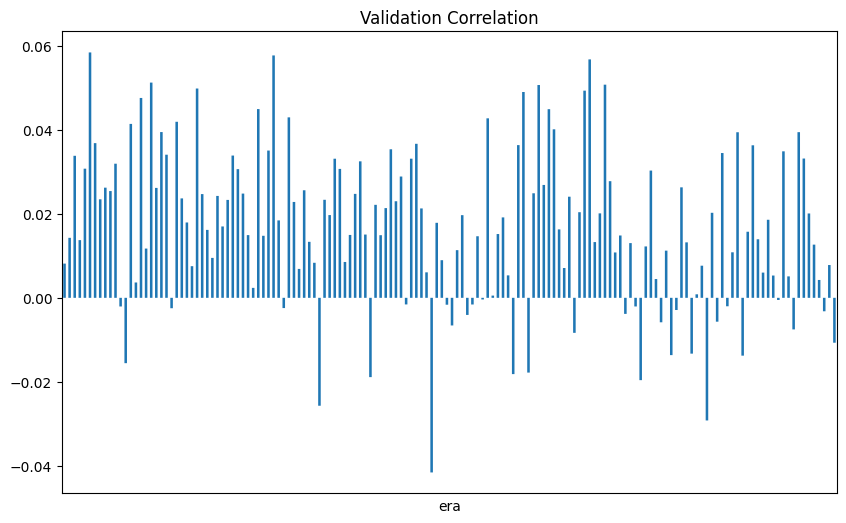

In [65]:
# Calcula la correlación por era entre nuestras predicciones y los valores "target".
per_era_corr = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))

# Gráfica de correlación por "era" 
per_era_corr.plot(kind="bar", title="Validation Correlation", figsize=(10, 6), xticks=[], snap=False);

En lugar de observar la puntuación "corr" de cada "era", resulta útil observar la puntuación "corr" acumulativa.

Esto se denomina "backtesting" en finanzas cuantitativas, donde las personas simulan el desempeño histórico de sus estrategias de inversión, puede considerar este gráfico como una prueba retrospectiva del desempeño de tu modelo durante el período de validación histórica.

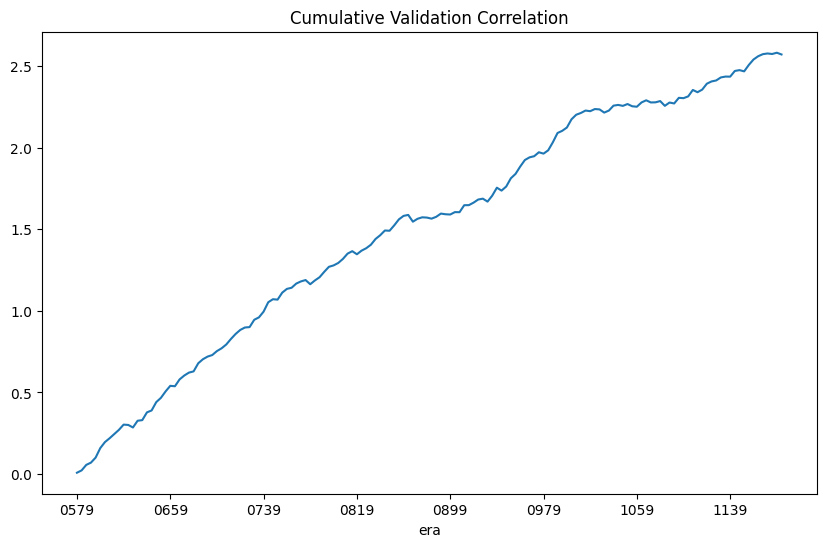

In [66]:
# Gráfica de la correlación acumulada por "era"
per_era_corr.cumsum().plot(kind="line", title="Cumulative Validation Correlation", figsize=(10, 6));

Métricas de rendimiento:
    
Para evaluar el rendimiento de nuestro modelo, también es útil calcular algunas métricas resumidas durante todo el período de validación.

La media de correlaciones es la medida principal del rendimiento de su modelo.

Sharpe es una medida de la coherencia de tu modelo, un concepto tomado de las finanzas, donde generalmente se refiere a los rendimientos ajustados al riesgo de una estrategia de inversión. Aquí calcularemos Sharpe como la correlación promedio dividida por la desviación estándar de las correlaciones.

La reducción máxima (max_drawdown) es una medida del riesgo de tu modelo, otro concepto tomado de las finanzas, donde generalmente se refiere a la pérdida financiera máxima sufrida por una estrategia de inversión. Aquí calcularemos la reducción máxima como la caída máxima desde el pico hasta el mínimo en la correlación de validación acumulativa.

In [67]:
# Calcula métricas de rendimiento
corr_mean = per_era_corr.mean()
corr_std = per_era_corr.std(ddof=0)
corr_sharpe = corr_mean / corr_std
max_drawdown = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()

pd.DataFrame({
    "mean": corr_mean,
    "std": corr_std,
    "sharpe": corr_sharpe,
    "max_drawdown": max_drawdown
}, index=["Value"]).T

,Value
mean,0.016923
std,0.018835
sharpe,0.898501
max_drawdown,0.041581


Estas métricas de rendimiento anteriores no son sorprendentes, pero son lo suficientemente buenas como para comenzar!

SUBMISSIONS

Vamos a evaluar los modelos según su rendimiento en vivo!

La tarea es generar predicciones sobre valores objetivo desconocidos, que representan los rendimientos del mercado de valores dentro de X días.

In [68]:
# Descargar las últimas entradas en tiempo real
napi.download_dataset(f"{DATA_VERSION}/live.parquet")

# Carga dichas características
live_features = pd.read_parquet(f"{DATA_VERSION}/live.parquet", columns=feature_set)

# Genera predicciones en vivo
live_predictions = model.predict(live_features[feature_set])

#Evaluar
live_predictions

# Envío
pd.Series(live_predictions, index=live_features.index).to_frame("prediction")

2025-11-04 19:25:54,838 INFO numerapi.utils: target file already exists
2025-11-04 19:25:54,839 INFO numerapi.utils: download complete


,prediction
id,
n00033945c89dc2a,0.504489
n000da32a2de4eb4,0.496172
n0010d47e977cc92,0.509463
n001d6e7f5876c97,0.492819
n002864576a9ecb2,0.508515
...,...
nffc3cc2110aea62,0.507681
nffe2b5eb838a44d,0.507715
nffe32840bab2a91,0.502967


## Librerias necesarias

In [69]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,ConfusionMatrixDisplay
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score, median_absolute_error


## Funciones auxiliares

In [70]:
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)

## Exploracion del dataset : EDA

In [71]:
train.describe()

,target,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,feature_donnard_groutier_twinkle,...,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
count,688184.000000,688184.000000,688184.000000,688184.000000,688184.000000,688184.000000,688184.000000,688184.000000,688184.000000,688184.000000,...,688184.000000,688184.000000,688184.000000,688184.000000,688184.000000,688184.000000,688184.000000,688184.000000,688184.000000,688184.000000
mean,0.500008,1.999916,1.999951,1.999936,1.999930,1.999936,1.999910,1.999910,1.999936,1.999936,...,1.999910,1.999910,1.999910,1.999910,1.999910,1.999936,1.999930,1.999910,1.999910,1.999916
std,0.223148,1.401563,1.097296,1.312527,1.373752,1.322029,1.414352,1.414352,1.322029,1.322029,...,1.414352,1.414352,1.414352,1.414352,1.414352,1.322029,1.373752,1.414352,1.414352,1.401563
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,0.500000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
75%,0.500000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
max,1.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


### Dimenciones y tipos

In [72]:
train.shape

(688184, 44)

In [73]:
train.dtypes

era                                               object
target                                           float32
feature_antistrophic_striate_conscriptionist        int8
feature_bicameral_showery_wallaba                   int8
feature_bridal_fingered_pensioner                   int8
feature_collectivist_flaxen_gueux                   int8
feature_concurring_fabled_adapter                   int8
feature_crosscut_whilom_ataxy                       int8
feature_departmental_inimitable_sentencer           int8
feature_dialectal_homely_cambodia                   int8
feature_donnard_groutier_twinkle                    int8
feature_elusive_vapoury_accomplice                  int8
feature_geminate_crummiest_scourer                  int8
feature_glandered_unimproved_peafowl                int8
feature_hempen_unionist_cone                        int8
feature_illuminated_gambrel_noria                   int8
feature_jacobinical_symmetric_roll                  int8
feature_jewish_stained_disembow

### Valores faltantes -Nulos- y distribución

In [74]:
print("Valores nulos por columna:")
print(train.isnull().sum())

Valores nulos por columna:
era                                              0
target                                           0
feature_antistrophic_striate_conscriptionist     0
feature_bicameral_showery_wallaba                0
feature_bridal_fingered_pensioner                0
feature_collectivist_flaxen_gueux                0
feature_concurring_fabled_adapter                0
feature_crosscut_whilom_ataxy                    0
feature_departmental_inimitable_sentencer        0
feature_dialectal_homely_cambodia                0
feature_donnard_groutier_twinkle                 0
feature_elusive_vapoury_accomplice               0
feature_geminate_crummiest_scourer               0
feature_glandered_unimproved_peafowl             0
feature_hempen_unionist_cone                     0
feature_illuminated_gambrel_noria                0
feature_jacobinical_symmetric_roll               0
feature_jewish_stained_disembowelment            0
feature_lacklustre_centroidal_schweitzer         0
feat

### Distribucion por era

<Axes: title={'center': 'Filas por  era'}, xlabel='era'>

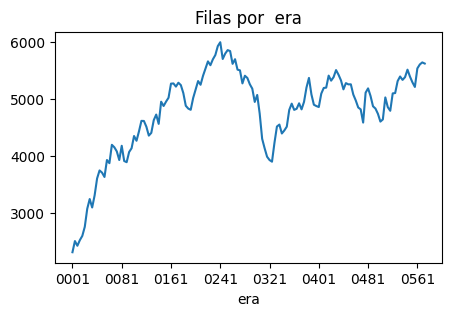

In [75]:
train.groupby('era').size().plot(title='Filas por  era',figsize=(5,3))

In [76]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 688184 entries, n0007b5abb0c3a25 to nfff87b21e4db902
Data columns (total 44 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   era                                            688184 non-null  object 
 1   target                                         688184 non-null  float32
 2   feature_antistrophic_striate_conscriptionist   688184 non-null  int8   
 3   feature_bicameral_showery_wallaba              688184 non-null  int8   
 4   feature_bridal_fingered_pensioner              688184 non-null  int8   
 5   feature_collectivist_flaxen_gueux              688184 non-null  int8   
 6   feature_concurring_fabled_adapter              688184 non-null  int8   
 7   feature_crosscut_whilom_ataxy                  688184 non-null  int8   
 8   feature_departmental_inimitable_sentencer      688184 non-null  int8   
 9   feature_dialectal

### Correlaciones con target

In [77]:
corr_target = train[feature_set + ['target']].corr()['target'].drop('target').sort_values(ascending=False)
corr_target.head(10)



feature_trimeter_soggy_greatest                0.009701
feature_willful_sere_chronobiology             0.009490
feature_stretchy_spiniest_fizgig               0.007674
feature_pottier_unmanly_collyrium              0.007612
feature_musicianly_aspirate_creativity         0.006951
feature_simulated_nonclassified_intercessor    0.006767
feature_petty_upraised_caddice                 0.006695
feature_unmodish_zymogenic_rousing             0.006398
feature_donnard_groutier_twinkle               0.005635
feature_hempen_unionist_cone                   0.005298
Name: target, dtype: float64

In [78]:
corr_target.tail(10)

feature_splanchnic_notional_pint               -0.003407
feature_unanalyzable_excusable_whirlwind       -0.003491
feature_zoological_peristomial_scute           -0.004507
feature_unbreakable_constraining_hegelianism   -0.006463
feature_saddening_unsound_rustling             -0.006704
feature_antistrophic_striate_conscriptionist   -0.006742
feature_transisthmian_yogic_linden             -0.006980
feature_departmental_inimitable_sentencer      -0.007156
feature_jewish_stained_disembowelment          -0.009227
feature_snakiest_somalian_wavelet              -0.010715
Name: target, dtype: float64

In [79]:
corr_directional = train[feature_set + ['target']].corr()['target'].drop('target').sort_values(ascending=False)
print("\nCorrelaciones con signo (para análisis):")
print(corr_directional.head(5))
print(corr_directional.tail(5))  



Correlaciones con signo (para análisis):
feature_trimeter_soggy_greatest           0.009701
feature_willful_sere_chronobiology        0.009490
feature_stretchy_spiniest_fizgig          0.007674
feature_pottier_unmanly_collyrium         0.007612
feature_musicianly_aspirate_creativity    0.006951
Name: target, dtype: float64
feature_antistrophic_striate_conscriptionist   -0.006742
feature_transisthmian_yogic_linden             -0.006980
feature_departmental_inimitable_sentencer      -0.007156
feature_jewish_stained_disembowelment          -0.009227
feature_snakiest_somalian_wavelet              -0.010715
Name: target, dtype: float64


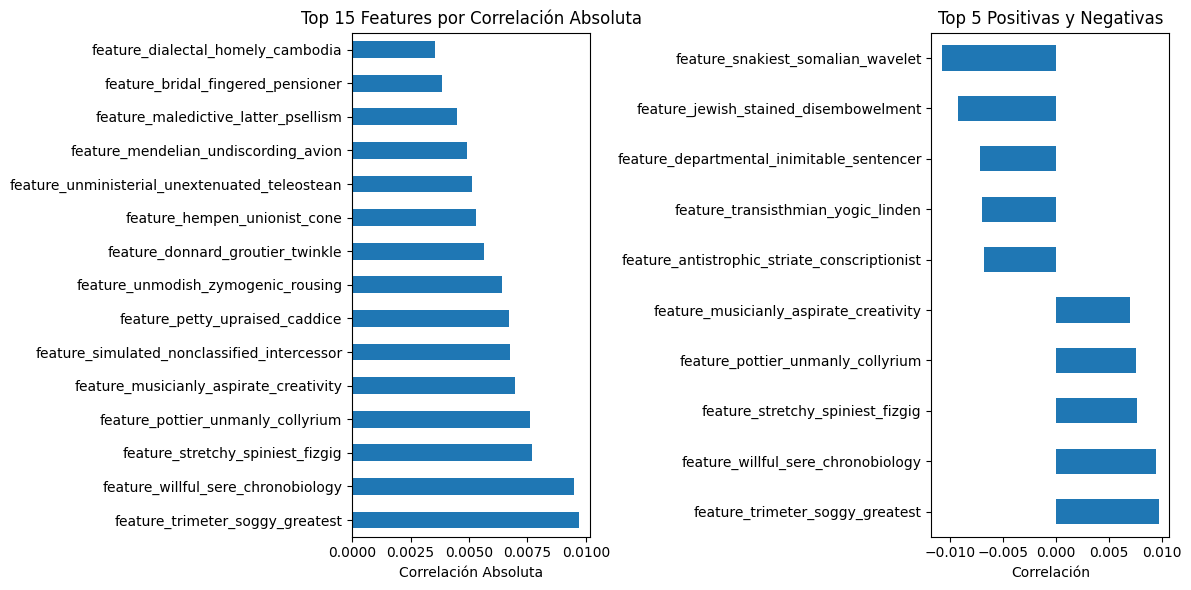

In [80]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
corr_target.head(15).plot(kind='barh')
plt.title('Top 15 Features por Correlación Absoluta')
plt.xlabel('Correlación Absoluta')

plt.subplot(1, 2, 2)
pd.concat([corr_directional.head(5), corr_directional.tail(5)]).plot(kind='barh')
plt.title('Top 5 Positivas y Negativas')
plt.xlabel('Correlación')

plt.tight_layout()
plt.show()


### Estabilidad por era

In [81]:
era_stats = train.groupby('era')[feature_set].mean().std().sort_values(ascending=False).head(10)
era_stats

feature_glandered_unimproved_peafowl        0.040768
feature_trimeter_soggy_greatest             0.000200
feature_limiest_heliolithic_york            0.000200
feature_lacklustre_centroidal_schweitzer    0.000200
feature_jewish_stained_disembowelment       0.000200
feature_toltec_korean_disfavourer           0.000200
feature_musicianly_aspirate_creativity      0.000200
feature_tridactyl_immoral_snorting          0.000200
feature_reclaimed_insurrectional_moneyer    0.000200
feature_elusive_vapoury_accomplice          0.000200
dtype: float64

### Grafico del target

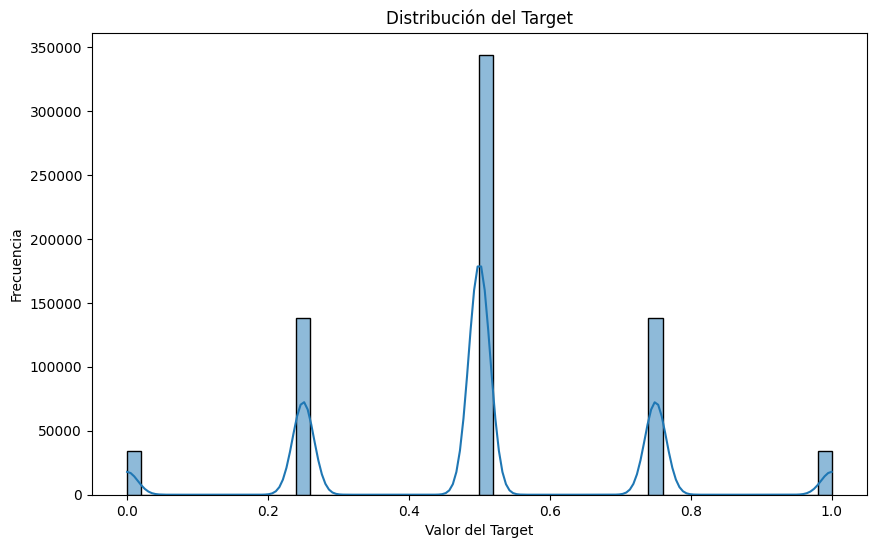

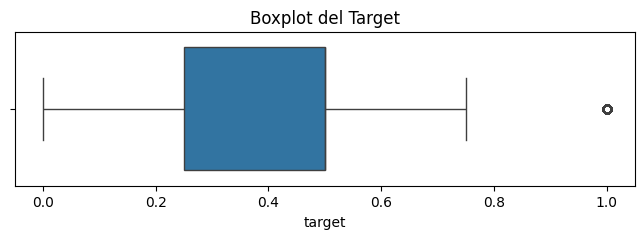

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Suponiendo que la columna target se llama 'target' y tu DataFrame se llama train o df
plt.figure(figsize=(10,6))
sns.histplot(train['target'], bins=50, kde=True)
plt.title('Distribución del Target')
plt.xlabel('Valor del Target')
plt.ylabel('Frecuencia')
plt.show()

# Extra: Boxplot para ver posibles outliers
plt.figure(figsize=(8, 2))
sns.boxplot(x=train['target'])
plt.title('Boxplot del Target')
plt.show()


### Identificar categoricas vs numericas

In [83]:
print('Variables categoricas:')
categoricas =train.select_dtypes(include=['object']).columns.tolist()
for col in categoricas:
    print(f'\nColumna: {col}')
    print(train[col].value_counts())
    print('Porcentaje:')
    print(round(train[col].value_counts(normalize=True) * 100, 2))

Variables categoricas:

Columna: era
era
0241    5988
0237    5920
0253    5850
0257    5833
0249    5789
        ... 
0017    2602
0013    2527
0005    2511
0009    2429
0001    2316
Name: count, Length: 144, dtype: int64
Porcentaje:
era
0241    0.87
0237    0.86
0253    0.85
0257    0.85
0249    0.84
        ... 
0017    0.38
0013    0.37
0005    0.36
0009    0.35
0001    0.34
Name: proportion, Length: 144, dtype: float64


In [84]:
print('Variables numericas:')
numericas = train.select_dtypes(include=['int64','int8','float64']).columns.tolist()

print(numericas)

Variables numericas:
['feature_antistrophic_striate_conscriptionist', 'feature_bicameral_showery_wallaba', 'feature_bridal_fingered_pensioner', 'feature_collectivist_flaxen_gueux', 'feature_concurring_fabled_adapter', 'feature_crosscut_whilom_ataxy', 'feature_departmental_inimitable_sentencer', 'feature_dialectal_homely_cambodia', 'feature_donnard_groutier_twinkle', 'feature_elusive_vapoury_accomplice', 'feature_geminate_crummiest_scourer', 'feature_glandered_unimproved_peafowl', 'feature_hempen_unionist_cone', 'feature_illuminated_gambrel_noria', 'feature_jacobinical_symmetric_roll', 'feature_jewish_stained_disembowelment', 'feature_lacklustre_centroidal_schweitzer', 'feature_limiest_heliolithic_york', 'feature_maledictive_latter_psellism', 'feature_mendelian_undiscording_avion', 'feature_musicianly_aspirate_creativity', 'feature_petty_upraised_caddice', 'feature_pottier_unmanly_collyrium', 'feature_reclaimed_insurrectional_moneyer', 'feature_saddening_unsound_rustling', 'feature_simu

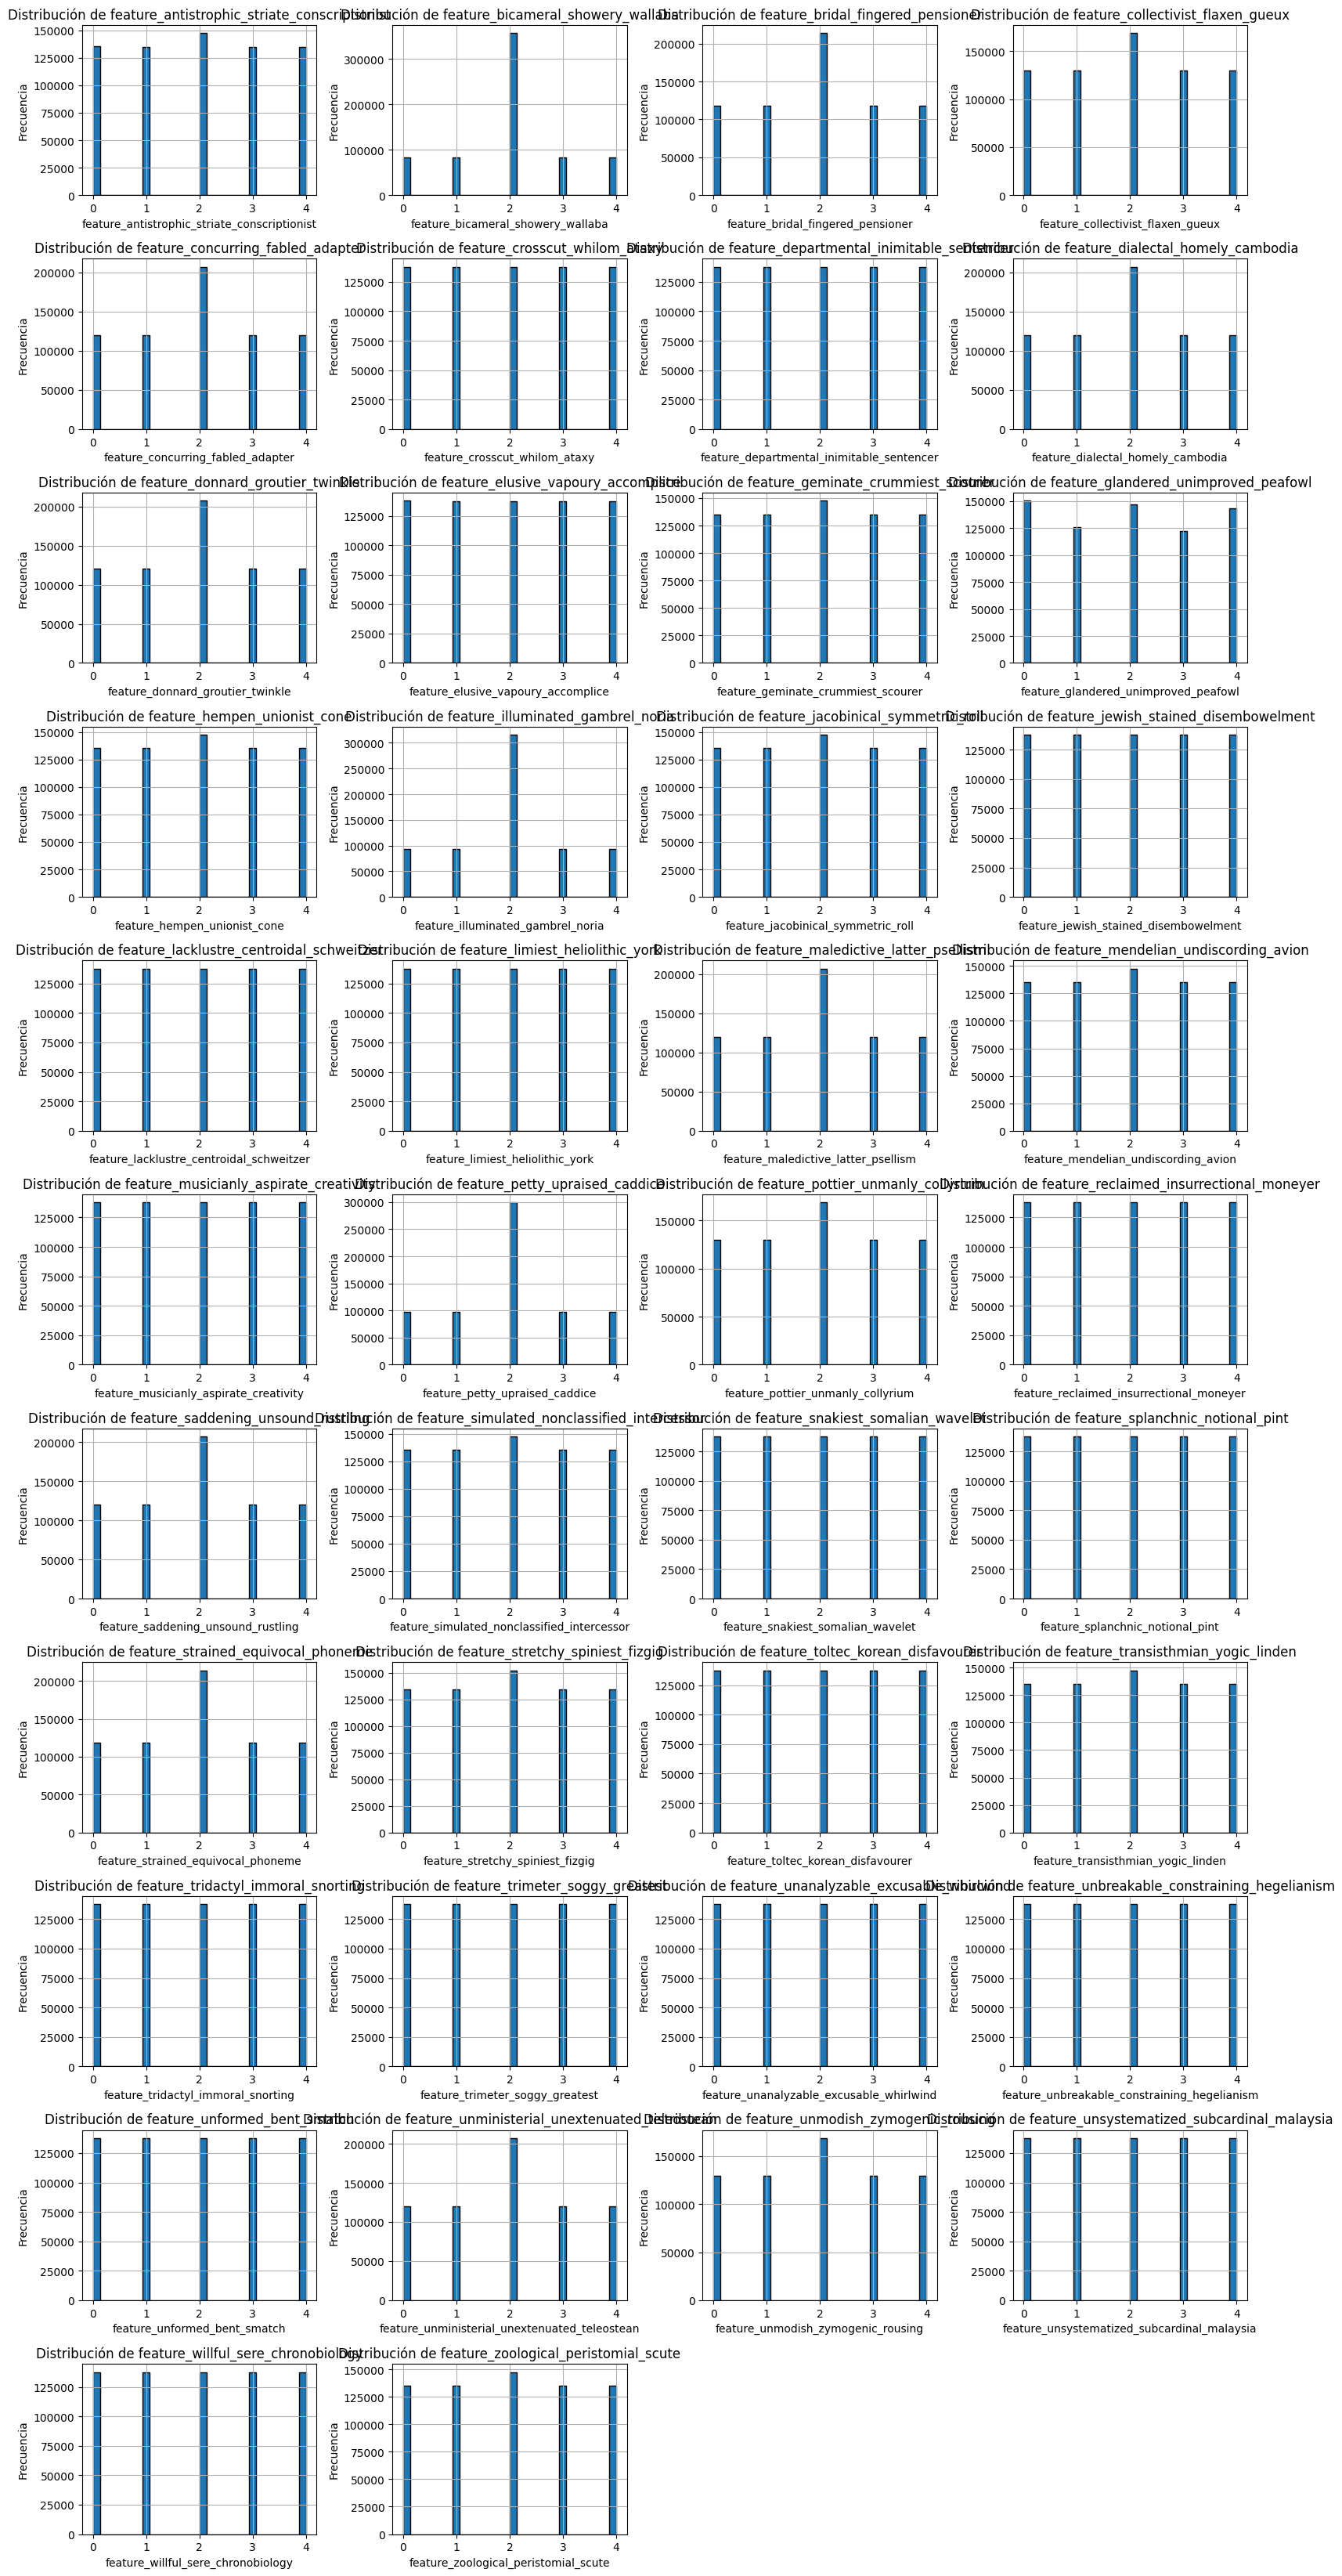

In [85]:

cols = [col for col in numericas if col != 'id']
n_plots = len(cols)
if n_plots == 0:
    print("No hay columnas numéricas para plotear.")
else:
    ncols = 4
    nrows = int(np.ceil(n_plots / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = np.array(axes).ravel()

    for idx, col in enumerate(cols):
        train[col].hist(bins=30, ax=axes[idx], edgecolor='black')
        axes[idx].set_title(f'Distribución de {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frecuencia')

    for ax in axes[n_plots:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

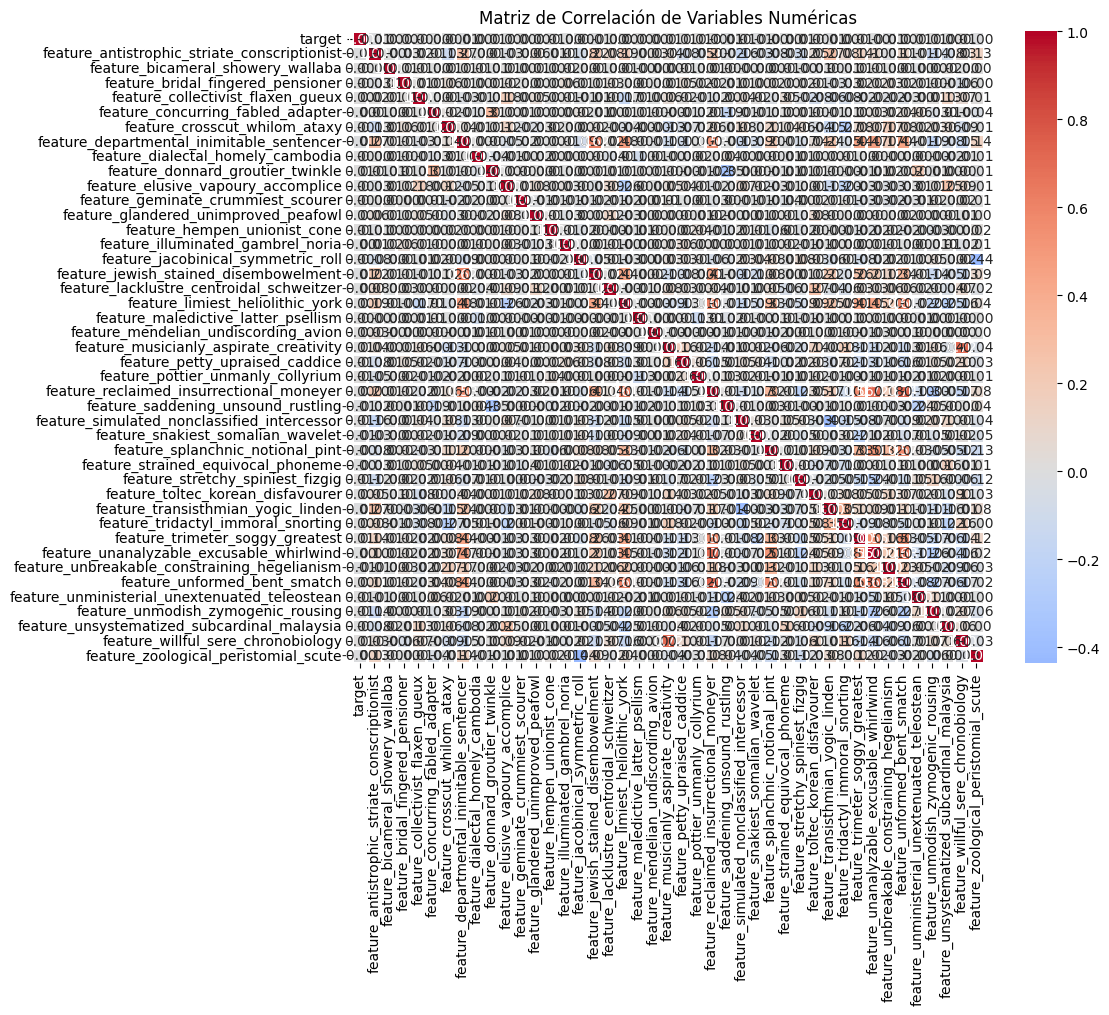


Correlación con 'target' (variable objetivo):
target                                           1.000000
feature_trimeter_soggy_greatest                  0.009701
feature_willful_sere_chronobiology               0.009490
feature_stretchy_spiniest_fizgig                 0.007674
feature_pottier_unmanly_collyrium                0.007612
feature_musicianly_aspirate_creativity           0.006951
feature_simulated_nonclassified_intercessor      0.006767
feature_petty_upraised_caddice                   0.006695
feature_unmodish_zymogenic_rousing               0.006398
feature_donnard_groutier_twinkle                 0.005635
feature_hempen_unionist_cone                     0.005298
feature_unministerial_unextenuated_teleostean    0.005112
feature_mendelian_undiscording_avion             0.004932
feature_maledictive_latter_psellism              0.004504
feature_bridal_fingered_pensioner                0.003844
feature_dialectal_homely_cambodia                0.003538
feature_toltec_korean_dis

<Figure size 640x480 with 0 Axes>

In [86]:
numeric_df = train.select_dtypes(include=['int64', 'int8', 'float64', 'float32'])

plt.figure(figsize=(12, 10))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.tight_layout()
plt.show()
plt.savefig('correlation_matrix.png')
print("\nCorrelación con 'target' (variable objetivo):")
print(correlation_matrix['target'].sort_values(ascending=False))

## Division de los datoa para entrenar modelo

In [87]:
train_set, val_set, test_set = train_val_test_split(train)

print(f"Training Set: {len(train_set)} muestras ({len(train_set)/len(train)*100:.1f}%)")
print(f"Validation Set: {len(val_set)} muestras ({len(val_set)/len(train)*100:.1f}%)")
print(f"Test Set: {len(test_set)} muestras ({len(test_set)/len(train)*100:.1f}%)")

Training Set: 412910 muestras (60.0%)
Validation Set: 137637 muestras (20.0%)
Test Set: 137637 muestras (20.0%)


In [88]:
print("\nDistribución del target en cada conjunto:")
print(f"Train: {train_set['target'].value_counts().to_dict()}")
print(f"Val:   {val_set['target'].value_counts().to_dict()}")
print(f"Test:  {test_set['target'].value_counts().to_dict()}")


Distribución del target en cada conjunto:
Train: {0.5: 206568, 0.25: 82838, 0.75: 82773, 0.0: 20392, 1.0: 20339}
Val:   {0.5: 68878, 0.25: 27607, 0.75: 27489, 0.0: 6832, 1.0: 6831}
Test:  {0.5: 68666, 0.75: 27667, 0.25: 27625, 1.0: 6907, 0.0: 6772}


In [89]:
print("Longitud del Training Set:", len(train_set))
print("Longitud del Validation Set:", len(val_set))
print("Longitud del Test Set:", len(test_set))

Longitud del Training Set: 412910
Longitud del Validation Set: 137637
Longitud del Test Set: 137637


In [90]:
X_train = train_set.drop(['target'], axis=1)
y_train = train_set['target'].copy()

In [91]:
X_test = test_set.drop(['target'], axis=1)
y_test = test_set['target'].copy()

In [92]:
X_val = val_set.drop(['target'], axis=1)
y_val = val_set['target'].copy()

In [93]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nColumnas en X_train:")
print(X_train.columns.tolist())

X_train shape: (412910, 43)
y_train shape: (412910,)

Columnas en X_train:
['era', 'feature_antistrophic_striate_conscriptionist', 'feature_bicameral_showery_wallaba', 'feature_bridal_fingered_pensioner', 'feature_collectivist_flaxen_gueux', 'feature_concurring_fabled_adapter', 'feature_crosscut_whilom_ataxy', 'feature_departmental_inimitable_sentencer', 'feature_dialectal_homely_cambodia', 'feature_donnard_groutier_twinkle', 'feature_elusive_vapoury_accomplice', 'feature_geminate_crummiest_scourer', 'feature_glandered_unimproved_peafowl', 'feature_hempen_unionist_cone', 'feature_illuminated_gambrel_noria', 'feature_jacobinical_symmetric_roll', 'feature_jewish_stained_disembowelment', 'feature_lacklustre_centroidal_schweitzer', 'feature_limiest_heliolithic_york', 'feature_maledictive_latter_psellism', 'feature_mendelian_undiscording_avion', 'feature_musicianly_aspirate_creativity', 'feature_petty_upraised_caddice', 'feature_pottier_unmanly_collyrium', 'feature_reclaimed_insurrectional_

## Preprocesamiento

In [94]:
feature_cols = [col for col in train.columns if col.startswith('feature')]

print('features : ',feature_cols)

features :  ['feature_antistrophic_striate_conscriptionist', 'feature_bicameral_showery_wallaba', 'feature_bridal_fingered_pensioner', 'feature_collectivist_flaxen_gueux', 'feature_concurring_fabled_adapter', 'feature_crosscut_whilom_ataxy', 'feature_departmental_inimitable_sentencer', 'feature_dialectal_homely_cambodia', 'feature_donnard_groutier_twinkle', 'feature_elusive_vapoury_accomplice', 'feature_geminate_crummiest_scourer', 'feature_glandered_unimproved_peafowl', 'feature_hempen_unionist_cone', 'feature_illuminated_gambrel_noria', 'feature_jacobinical_symmetric_roll', 'feature_jewish_stained_disembowelment', 'feature_lacklustre_centroidal_schweitzer', 'feature_limiest_heliolithic_york', 'feature_maledictive_latter_psellism', 'feature_mendelian_undiscording_avion', 'feature_musicianly_aspirate_creativity', 'feature_petty_upraised_caddice', 'feature_pottier_unmanly_collyrium', 'feature_reclaimed_insurrectional_moneyer', 'feature_saddening_unsound_rustling', 'feature_simulated_non

In [95]:
num_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('rbst_scaler',RobustScaler()),
])

data_preparer = ColumnTransformer([
    ("num", num_pipeline, feature_cols),
])

print("✓ Pipeline numérico: Imputación (mediana) + RobustScaler")
print("✓ Pipeline categórico: Imputación (moda) + OneHotEncoder")
print("✓ ColumnTransformer creado")

✓ Pipeline numérico: Imputación (mediana) + RobustScaler
✓ Pipeline categórico: Imputación (moda) + OneHotEncoder
✓ ColumnTransformer creado


In [96]:
X_train_prep = data_preparer.fit_transform(X_train)
X_val_prep = data_preparer.transform(X_val)
X_test_prep = data_preparer.transform(X_test)

print(f"X_train original: {X_train.shape}")
print(f"X_train preprocesado: {X_train_prep.shape}")
print(f"\nX_val preprocesado: {X_val_prep.shape}")
print(f"X_test preprocesado: {X_test_prep.shape}")

X_train original: (412910, 43)
X_train preprocesado: (412910, 42)

X_val preprocesado: (137637, 42)
X_test preprocesado: (137637, 42)


## Entrenamos el modelo

### Empiezo con random forest ya que tiene buena base

In [97]:
rf = RandomForestRegressor(n_estimators=150,max_depth=6,random_state=42,n_jobs=-1)

rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

## XGBoost

In [98]:
!pip install xgboost


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [99]:
from xgboost import XGBRegressor
X_train_xgb = X_train.copy()
X_val_xgb = X_val.copy()
X_test_xgb = X_test.copy()

le = LabelEncoder()
X_train_xgb['era'] = le.fit_transform(X_train_xgb['era'])
X_val_xgb['era'] = le.transform(X_val_xgb['era'])
X_test_xgb['era'] = le.transform(X_test_xgb['era'])

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1  
)

xgb.fit(X_train_xgb, y_train)
y_pred_xgb = xgb.predict(X_test_xgb)

In [100]:
print("Resultados para XGBoost:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("MAE:", mean_absolute_error(y_val, y_pred_xgb))
print("R2:", r2_score(y_val, y_pred_xgb))
print("Correlación Pearson:", np.corrcoef(y_test, y_pred_xgb)[0, 1])

Resultados para XGBoost:
RMSE: 0.2236889931020603
MAE: 0.15702565014362335
R2: -0.007181048393249512
Correlación Pearson: 0.0330125763332719



Resultados para Random Forest:
MSE: 0.04989687002776283
RMSE: 0.2233760730869867
MAE: 0.15173762568880034
Mediana Error Absoluto: 0.23581020434296274
R2: 0.0011345134037857862
Explained Variance: 0.0011438115623235712
Correlación Pearson: 0.03833812150776178


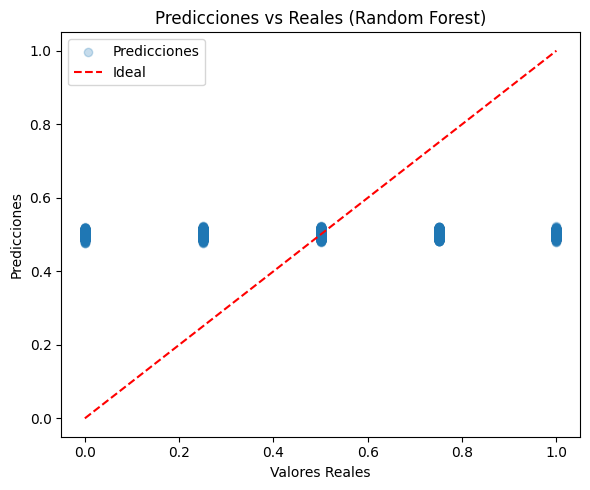


Resultados para XGBoost :
MSE: 0.05003676563501358
RMSE: 0.2236889931020603
MAE: 0.15670627355575562
Mediana Error Absoluto: 0.18764007091522217
R2: -0.001665949821472168
Explained Variance: -0.0016559362411499023
Correlación Pearson: 0.0330125763332719


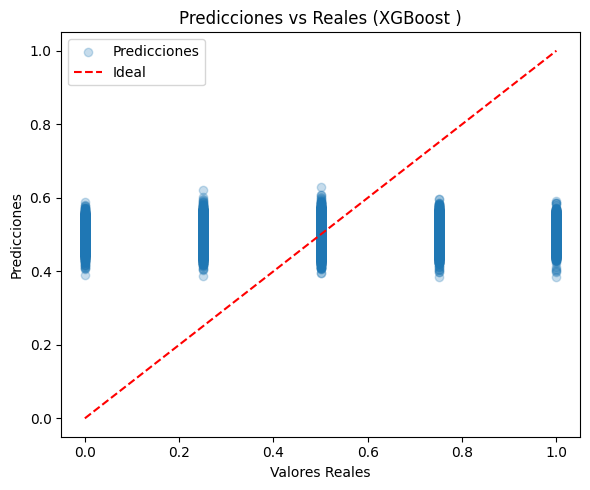

In [101]:
def print_metrics(y_true, y_pred, nombre):
    print(f"\nResultados para {nombre}:")
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("Mediana Error Absoluto:", median_absolute_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))
    print("Explained Variance:", explained_variance_score(y_true, y_pred))
    print("Correlación Pearson:", np.corrcoef(y_true, y_pred)[0, 1])

    plt.figure(figsize=(6, 5))
    plt.scatter(y_true, y_pred, alpha=0.25, label="Predicciones")
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], '--', color='r', label="Ideal")
    plt.xlabel("Valores Reales")
    plt.ylabel("Predicciones")
    plt.title(f"Predicciones vs Reales ({nombre})")
    plt.legend()
    plt.tight_layout()
    plt.show()

print_metrics(y_test, y_pred_rf, "Random Forest")
print_metrics(y_test, y_pred_xgb, "XGBoost ")

                  Modelo    RMSE     MAE      R2  ExplainedVariance  \
0  RandomForestRegressor  0.2234  0.1517  0.0011             0.0011   
1                XGBoost  0.2237  0.1567 -0.0017            -0.0017   

   Correlación  
0       0.0383  
1       0.0330  


<Figure size 1000x600 with 0 Axes>

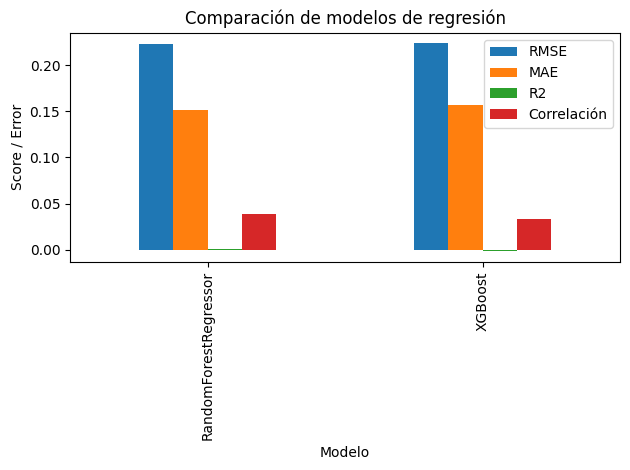

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import numpy as np


modelos = ['RandomForestRegressor', 'XGBoost']
y_preds = [y_pred_rf, y_pred_xgb]

resultados = {
    'Modelo': modelos,
    'RMSE': [],
    'MAE': [],
    'R2': [],
    'ExplainedVariance': [],
    'Correlación': []
}

for y_pred in y_preds:
    resultados['RMSE'].append(np.sqrt(mean_squared_error(y_test, y_pred)))
    resultados['MAE'].append(mean_absolute_error(y_test, y_pred))
    resultados['R2'].append(r2_score(y_test, y_pred))
    resultados['ExplainedVariance'].append(explained_variance_score(y_test, y_pred))
    resultados['Correlación'].append(np.corrcoef(y_test, y_pred)[0, 1])

resultados_modelos = pd.DataFrame(resultados)
print(resultados_modelos.round(4))


plt.figure(figsize=(10,6))
resultados_modelos.plot(x='Modelo', y=['RMSE','MAE','R2','Correlación'], kind='bar')
plt.title('Comparación de modelos de regresión')
plt.ylabel('Score / Error')
plt.tight_layout()
plt.savefig('regression_model_comparison.png')
plt.show()


In [103]:
def feature_neutralization(predictions, features, proportion=0.5):
    
    if isinstance(predictions, pd.Series):
        predictions = predictions.to_frame('prediction')
    
    X = features.copy()
    
    from sklearn.linear_model import LinearRegression
    lr = LinearRegression()
    lr.fit(X, predictions['prediction'])
    
    feature_component = lr.predict(X)
    
    neutralized_preds = predictions['prediction'] - proportion * feature_component
    
    return neutralized_preds


## Validacion con los datos descargados

### Preparacion

In [104]:
cols_rf = X_train.columns.tolist()

validation_num = data_preparer.transform(validation[feature_cols])
validation_num_df = pd.DataFrame(validation_num, columns=feature_cols)
validation_num_df.index = validation.index

validation_rf = pd.concat([validation_num_df, validation[['era']].reset_index(drop=True)], axis=1)


validation_rf = validation_rf[cols_rf]




### Ahora lo usamos con RandomForestRegressor

In [105]:
validation_rf = pd.concat([validation[['era']], validation_num_df], axis=1)[cols_rf]

validation['prediction_rf'] = rf.predict(validation_rf)

neutral_preds_rf = feature_neutralization(
    validation['prediction_rf'],
    validation_rf,
    proportion=0.3
)
validation['prediction_neutral_rf'] = neutral_preds_rf


### Evaluacion de correlacion para ambos modelos

In [106]:
print("RF:")
original_corr_rf = practica_corr(validation['prediction_rf'], validation['target'])
neutral_corr_rf = practica_corr(validation['prediction_neutral_rf'], validation['target'])

print(f"  CORR original: {original_corr_rf:.4f}")
print(f"  CORR neutralizado: {neutral_corr_rf:.4f}")


RF:
  CORR original: 0.0033
  CORR neutralizado: 0.0024


In [107]:
print("Eras en entrenamiento (LabelEncoder):", set(le.classes_))
print("Eras en validation:", set(validation['era']))

Eras en entrenamiento (LabelEncoder): {'0321', '0137', '0069', '0357', '0309', '0533', '0417', '0169', '0017', '0189', '0409', '0345', '0497', '0177', '0305', '0509', '0249', '0385', '0273', '0025', '0209', '0289', '0333', '0545', '0065', '0049', '0361', '0369', '0393', '0525', '0181', '0205', '0397', '0001', '0021', '0105', '0141', '0437', '0421', '0517', '0113', '0405', '0325', '0061', '0441', '0337', '0317', '0161', '0037', '0245', '0089', '0193', '0053', '0253', '0005', '0561', '0521', '0269', '0297', '0489', '0557', '0301', '0313', '0565', '0117', '0481', '0233', '0173', '0569', '0057', '0433', '0077', '0045', '0041', '0149', '0329', '0529', '0261', '0085', '0477', '0217', '0449', '0501', '0097', '0241', '0229', '0473', '0549', '0213', '0201', '0153', '0185', '0125', '0225', '0429', '0537', '0353', '0413', '0457', '0573', '0401', '0461', '0485', '0281', '0505', '0389', '0033', '0073', '0377', '0445', '0465', '0541', '0101', '0469', '0493', '0197', '0221', '0145', '0277', '0425', '

In [108]:
import cloudpickle

with open('modelo_dataScience.pkl', 'wb') as archivo:
    cloudpickle.dump(rf, archivo)

with open('modelo_dataScience_xgb.pkl', 'wb') as archivo:
    cloudpickle.dump(xgb, archivo)




## Respuestas del PDF

### Reduce el conjunto de datos, eliminando filas (si así lo consideras), si se vuelve muy pesado el entrenamiento. Justifícalo.

    - No hizo falta eliminar filas ni reducir los datos ya que se esta trabajando con el modelo small y ya de por si tiene pocos datos que permite realizar el entrenamiento del modelo sin restricciones de memoria y en tiempos razonables.

#### Aplica PCA para reducir la dimensionalidad. ¿Cuántas características resultan y por qué?

    - No se aplico PCA debido a que por la cantidad de datos del dataset no hizo falta reducir mas las dimenciones del mismo ya que permite trabajar eficientemente sin riesgo de sobreajuste ni problemas de computación asociados a la alta dimensionalidad.

### Has aplicado preprocesamiento?¿escalado/normalización o estandarización?¿por qué?

    - Se utilizó el RobustScaler para asegurar que todas las variables numéricas tengan una escala comparable y que los modelos sean más robustos frente a posibles valores atípicos, lo cual es especialmente relevante en problemáticas financieros.